# ACO for CVRP — B-Series Analysis

Comparative analysis of Greedy, ACO, EAS, and MMAS on CVRPLIB B-series instances.

In [16]:
%matplotlib inline
import json, pathlib, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt

sys.path.insert(0, "..")
from src.viz import plot_routes, plot_convergence, plot_convergence_derivative, plot_boxplots, plot_scaling
from src.vrp import load_vrp, load_sol
from src.solution import compute_total_dist

MAIN_DIR   = pathlib.Path("../results/B")
SWEEP_DIR  = pathlib.Path("../results/sweep_B")
DATA_DIR   = pathlib.Path("../data/B")

df = pd.read_csv(MAIN_DIR / "results.csv")
df["feasible"] = df["feasible"].astype(bool)
df["relative_error"] = pd.to_numeric(df["relative_error"], errors="coerce")
df["s_max"] = pd.to_numeric(df["s_max"], errors="coerce")
main = df[df["feasible"] & df["s_max"].isna()]
print(f"Loaded {len(df)} runs, {len(main)} feasible unconstrained")

Loaded 360 runs, 115 feasible unconstrained


## H3.1 — Solution Quality

Mean relative error vs best-known across algorithms. Box plots show distribution across seeds.

=== Mean relative error vs best known ===


,mean,std,min
algorithm,,,
eas,0.1759,0.0578,0.1004
aco,0.1937,0.0840,0.1029
mmas,0.2160,0.0788,0.0895
greedy,0.5296,0.2432,0.2269



=== Mean total distance per instance ===


algorithm,aco,eas,greedy,mmas
instance,,,,
B-n31-k5,755.6,756.5,954.3,749.1
B-n39-k5,748.6,705.7,1060.2,739.1
B-n45-k6,779.2,769.1,NaN,807.7
B-n50-k7,887.7,873.8,1209.7,893.3
B-n57-k9,1824.8,1817.8,1960.7,1858.1
B-n78-k10,1446.8,1457.0,1755.0,1557.5


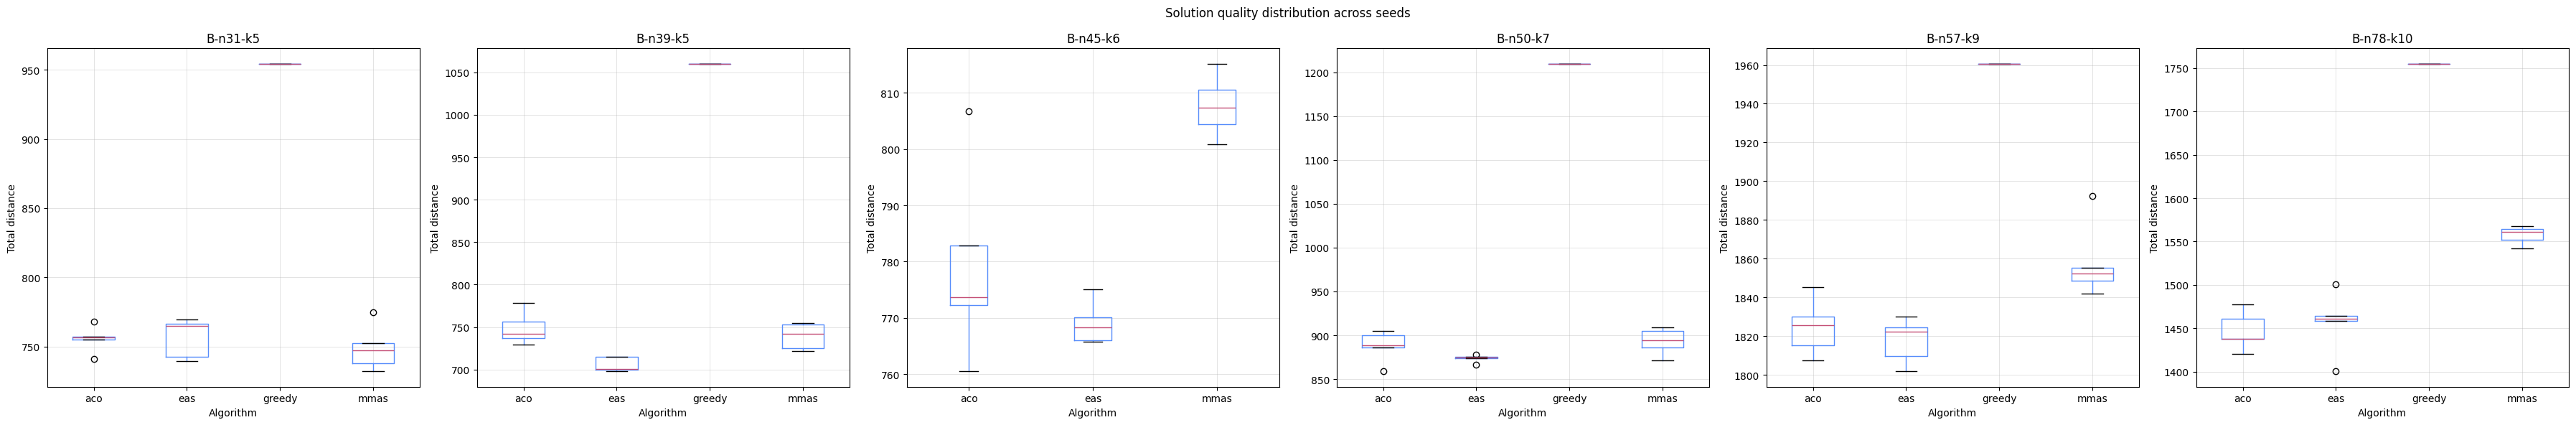

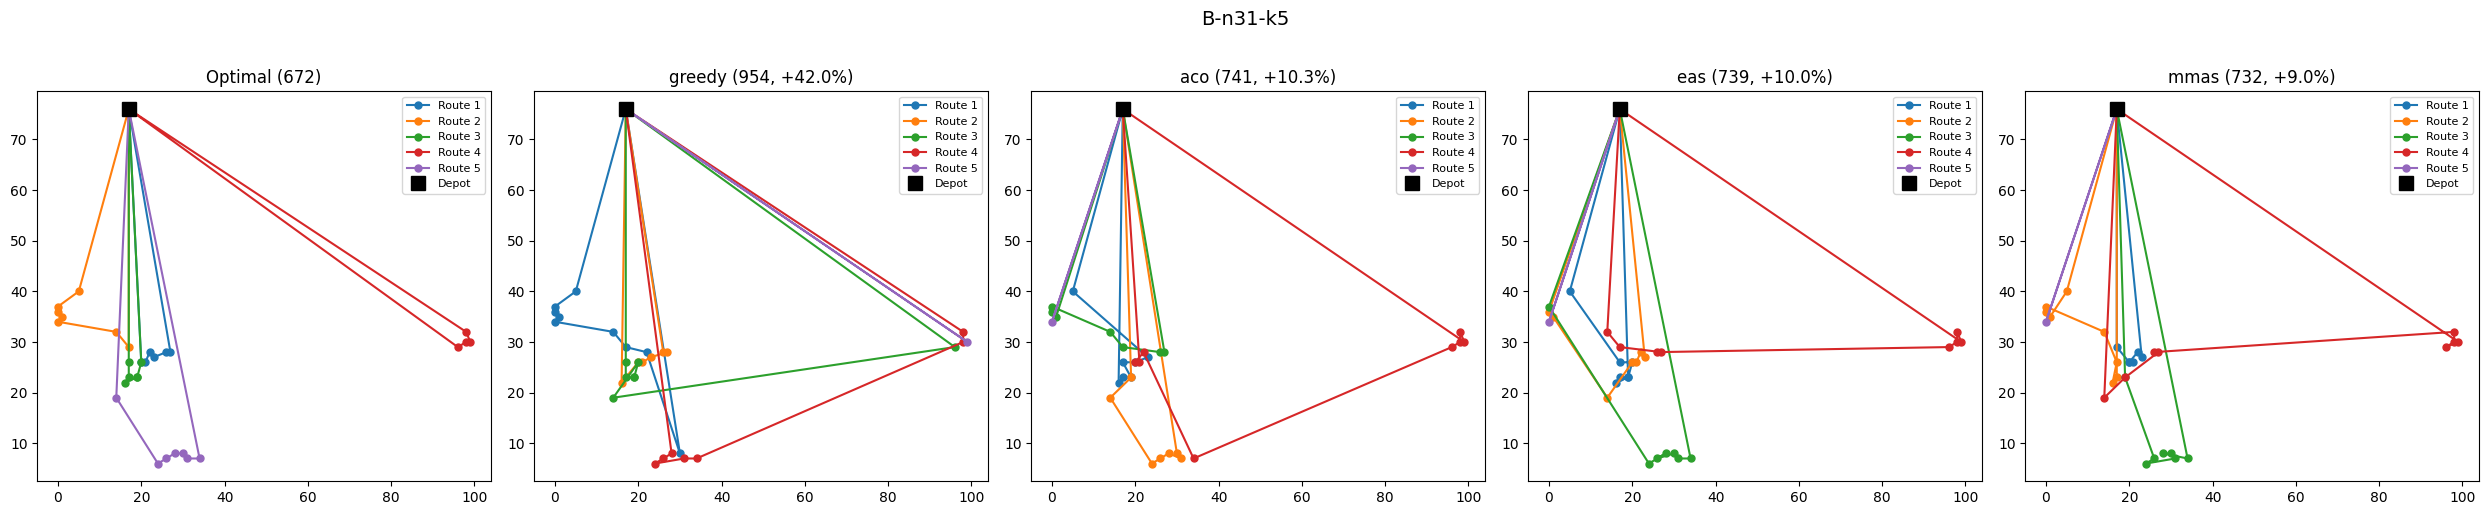

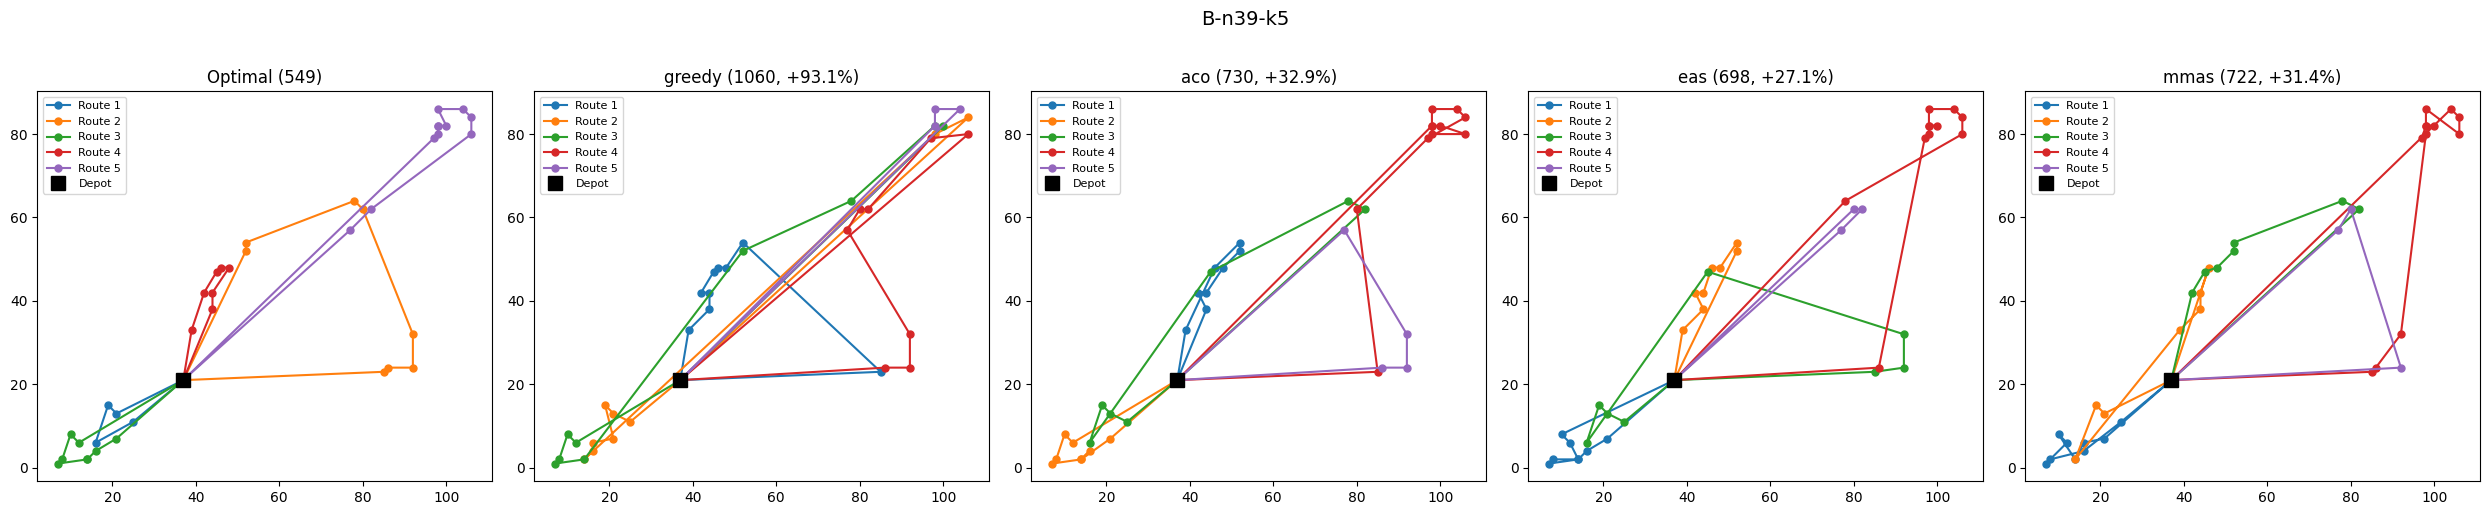

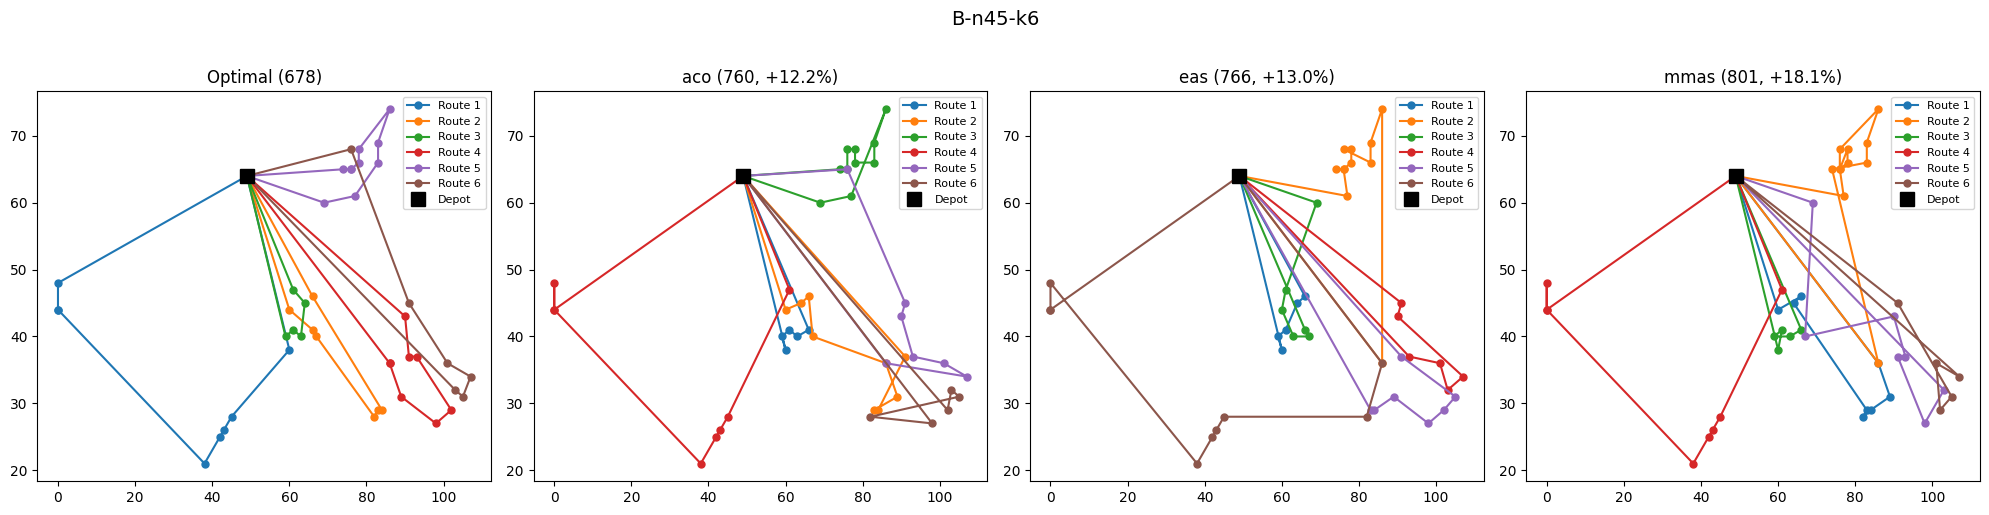

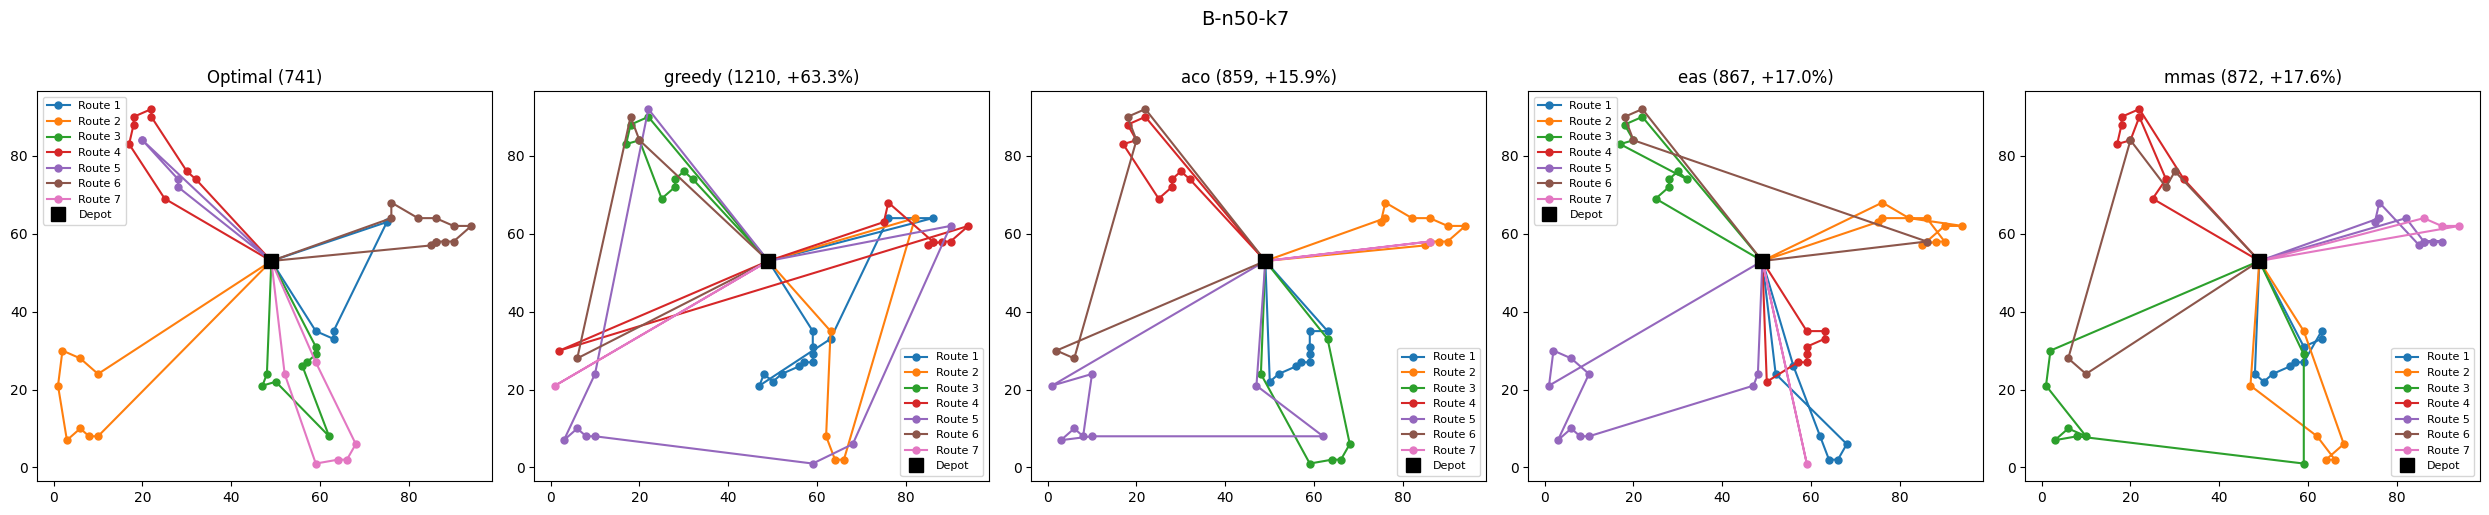

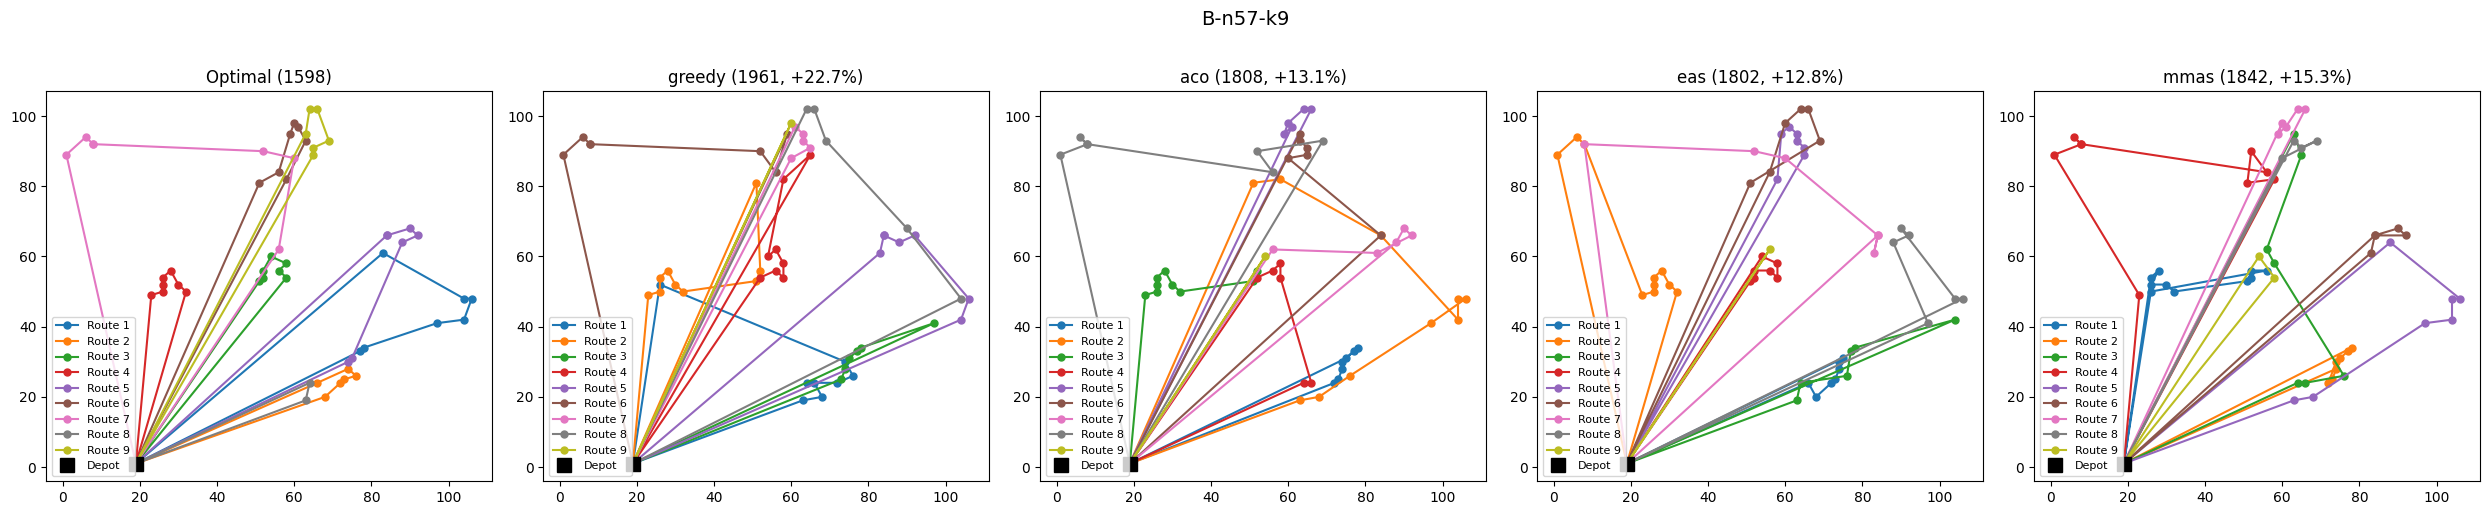

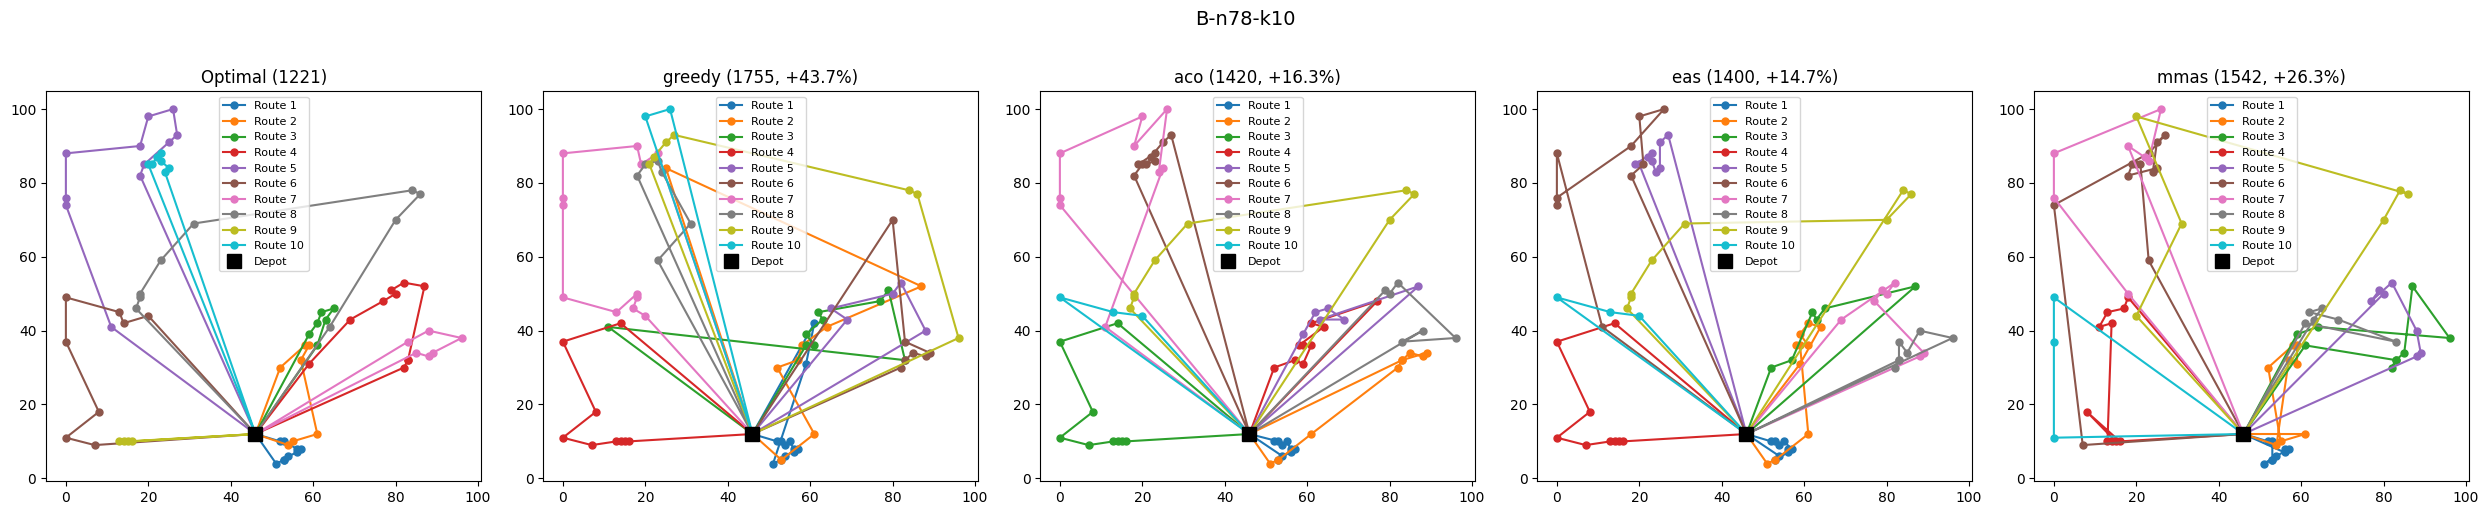

In [17]:
print("=== Mean relative error vs best known ===")
display(
    main.groupby("algorithm")["relative_error"]
    .agg(["mean", "std", "min"])
    .round(4)
    .sort_values("mean")
)

print("\n=== Mean total distance per instance ===")
display(
    main.groupby(["algorithm", "instance"])["total_dist"]
    .mean().round(1).unstack("algorithm")
)

plot_boxplots(main)

# --- Route comparison from JSON ---
json_files = list(MAIN_DIR.glob("*.json"))
all_runs = {}
for jf in json_files:
    run = json.loads(jf.read_text())
    if not run.get("feasible") or not run.get("routes") or run.get("s_max") is not None:
        continue
    key = (run["instance"], run["algorithm"])
    if key not in all_runs or run["total_dist"] < all_runs[key]["total_dist"]:
        all_runs[key] = run

instances = sorted({k[0] for k in all_runs})
algos = ["greedy", "aco", "eas", "mmas"]

for inst_name in instances:
    sol_path = DATA_DIR / f"{inst_name}.sol"
    vrp_path = DATA_DIR / f"{inst_name}.vrp"
    if not sol_path.exists() or not vrp_path.exists():
        continue
    inst = load_vrp(str(vrp_path))
    optimal_routes, optimal_cost = load_sol(str(sol_path))

    available = [(a, all_runs[(inst_name, a)]) for a in algos if (inst_name, a) in all_runs]
    n_cols = 1 + len(available)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
    if n_cols == 1:
        axes = [axes]

    plot_routes(optimal_routes, inst.coords, f"Optimal ({optimal_cost:.0f})", ax=axes[0])
    for i, (algo, run) in enumerate(available, 1):
        cost = run["total_dist"]
        re = (cost - optimal_cost) / optimal_cost * 100 if optimal_cost else 0
        plot_routes(run["routes"], inst.coords, f"{algo} ({cost:.0f}, +{re:.1f}%)", ax=axes[i])
    fig.suptitle(inst_name, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## H3.2 — Scalability

Relative error and runtime vs instance size.

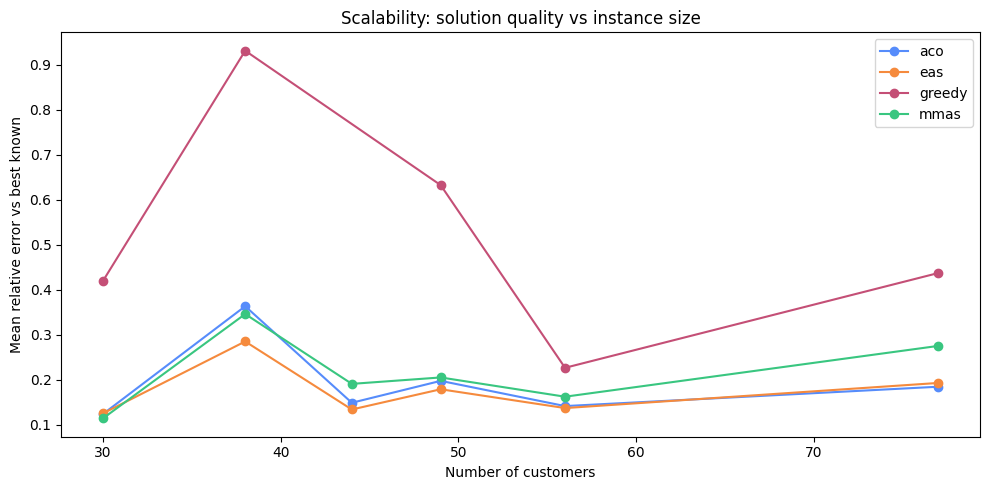

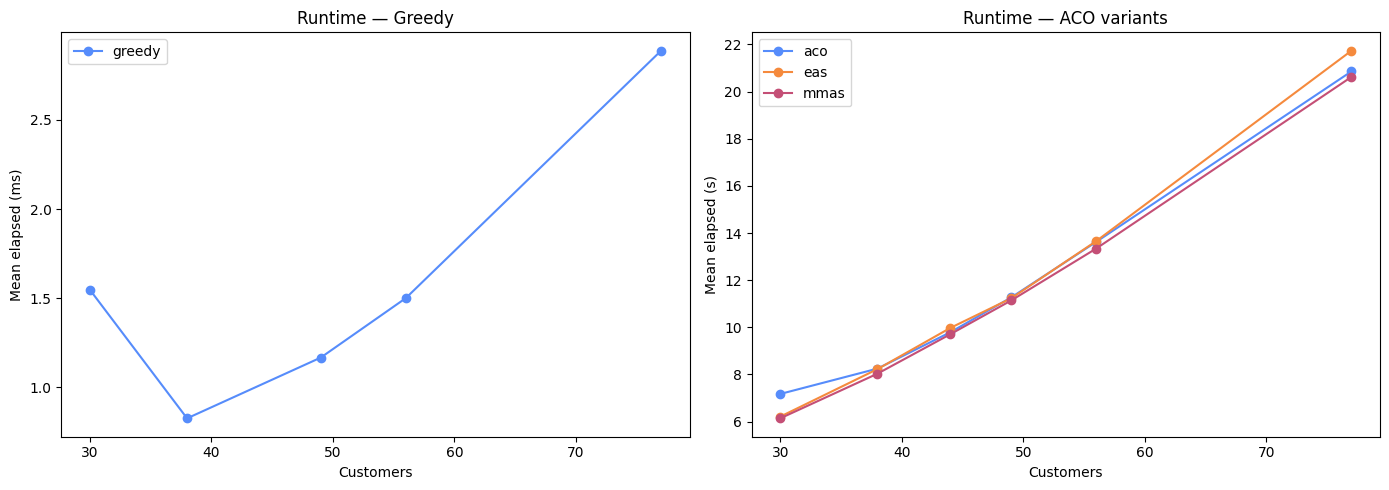

In [18]:
plot_scaling(main)

elapsed = main.groupby(["algorithm", "n_customers"])["elapsed_sec"].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: greedy (ms scale)
g_greedy = elapsed[elapsed["algorithm"] == "greedy"].sort_values("n_customers")
ax1.plot(g_greedy["n_customers"], g_greedy["elapsed_sec"] * 1000, "-o", label="greedy")
ax1.set_xlabel("Customers"); ax1.set_ylabel("Mean elapsed (ms)")
ax1.set_title("Runtime — Greedy"); ax1.legend()

# Right: ACO variants (s scale)
for algo in ["aco", "eas", "mmas"]:
    g = elapsed[elapsed["algorithm"] == algo].sort_values("n_customers")
    ax2.plot(g["n_customers"], g["elapsed_sec"], "-o", label=algo)
ax2.set_xlabel("Customers"); ax2.set_ylabel("Mean elapsed (s)")
ax2.set_title("Runtime — ACO variants"); ax2.legend()
plt.tight_layout()
plt.show()

## H3.3 — Convergence

Full convergence curves and smoothed improvement rate (derivative).

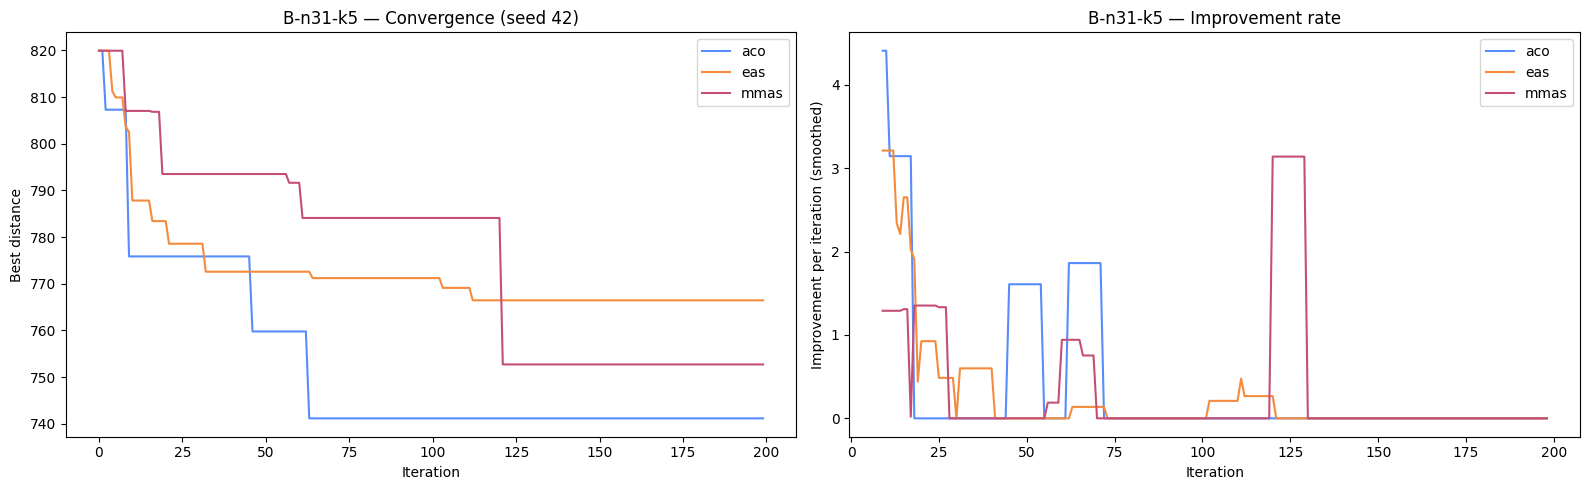

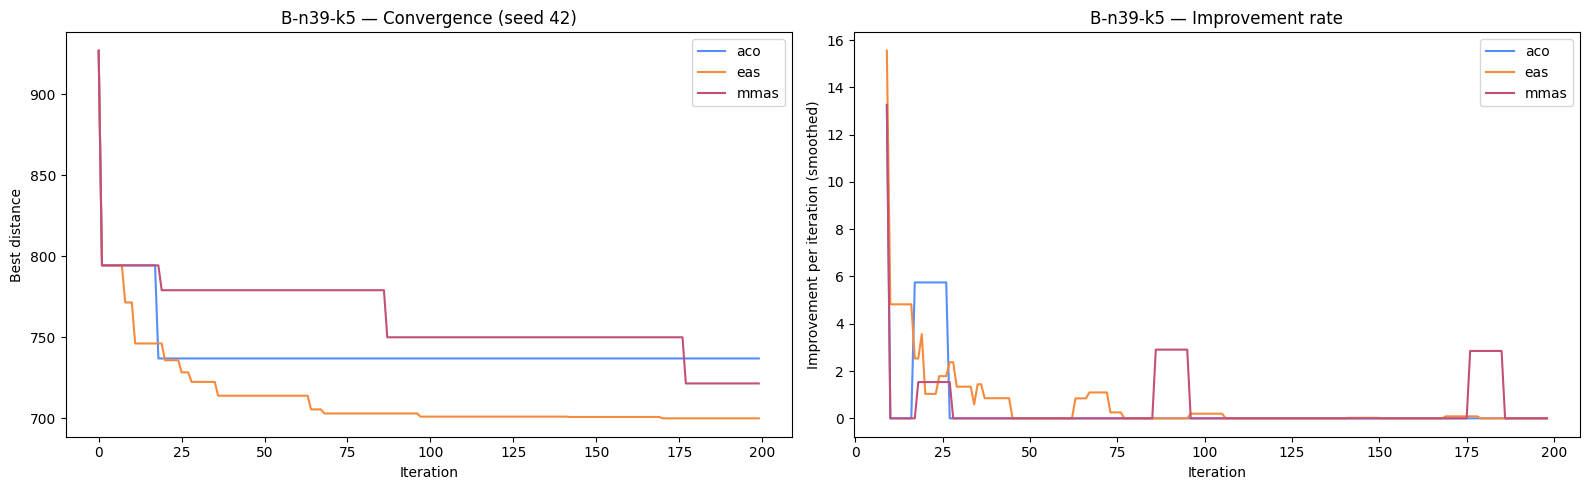

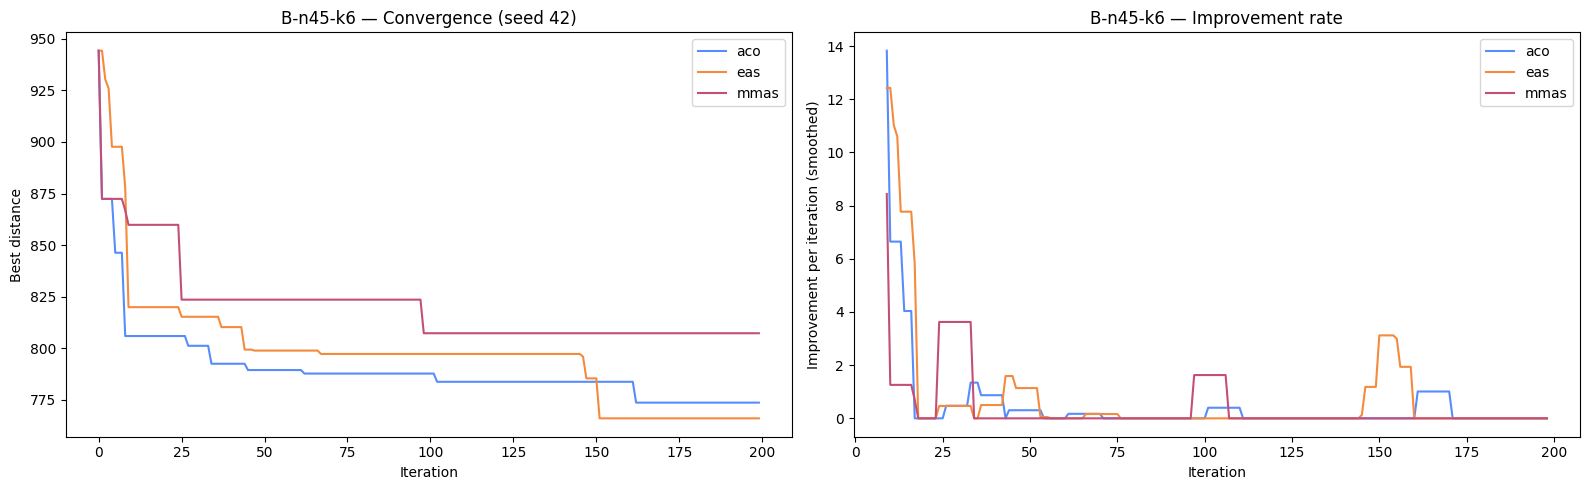

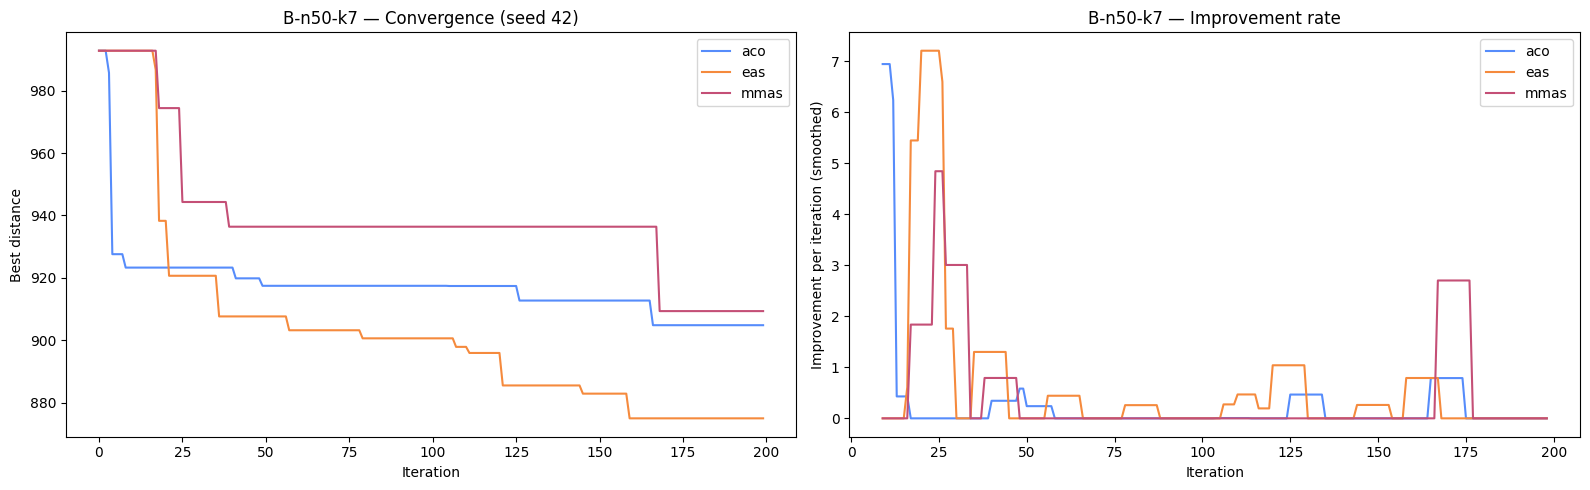

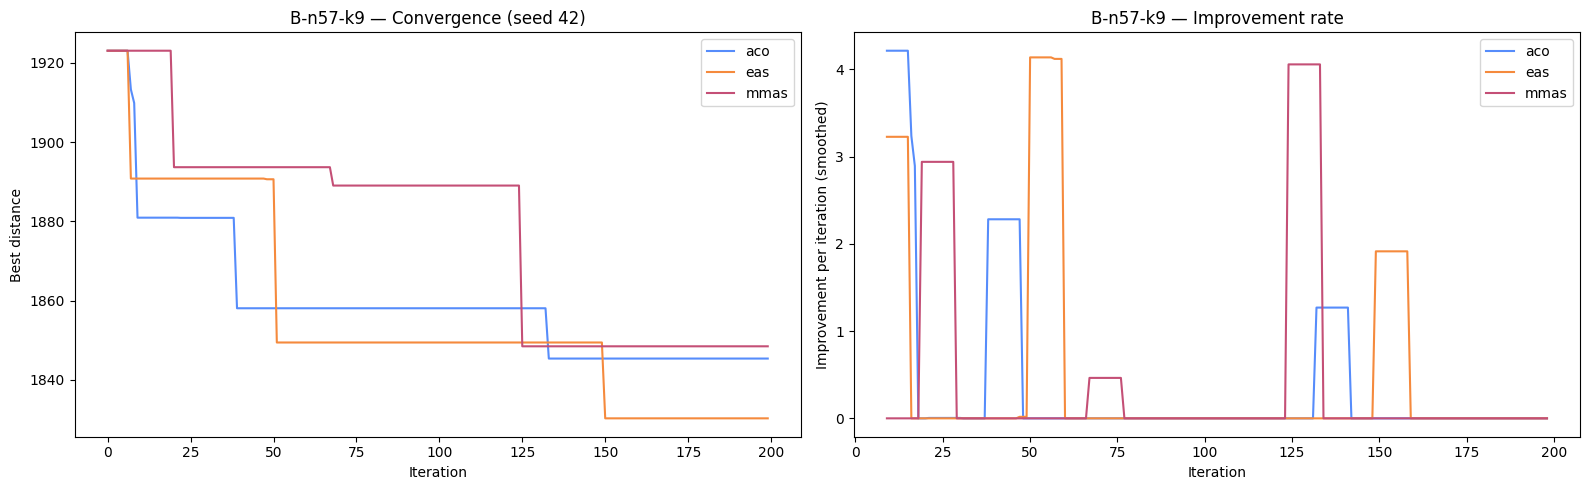

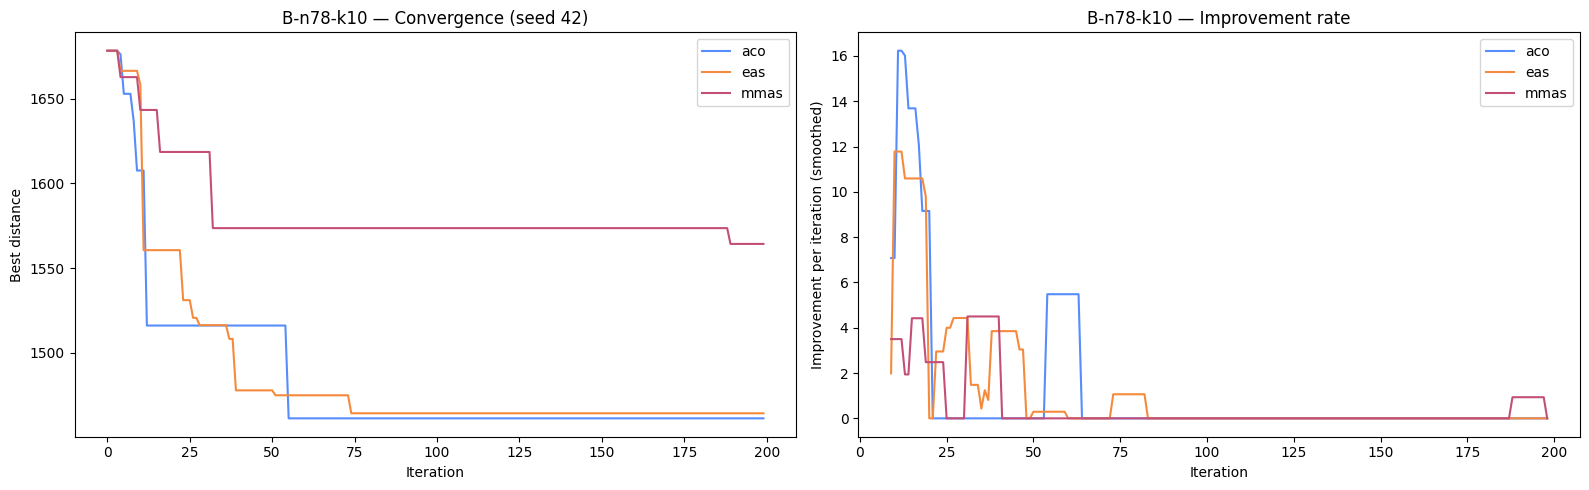

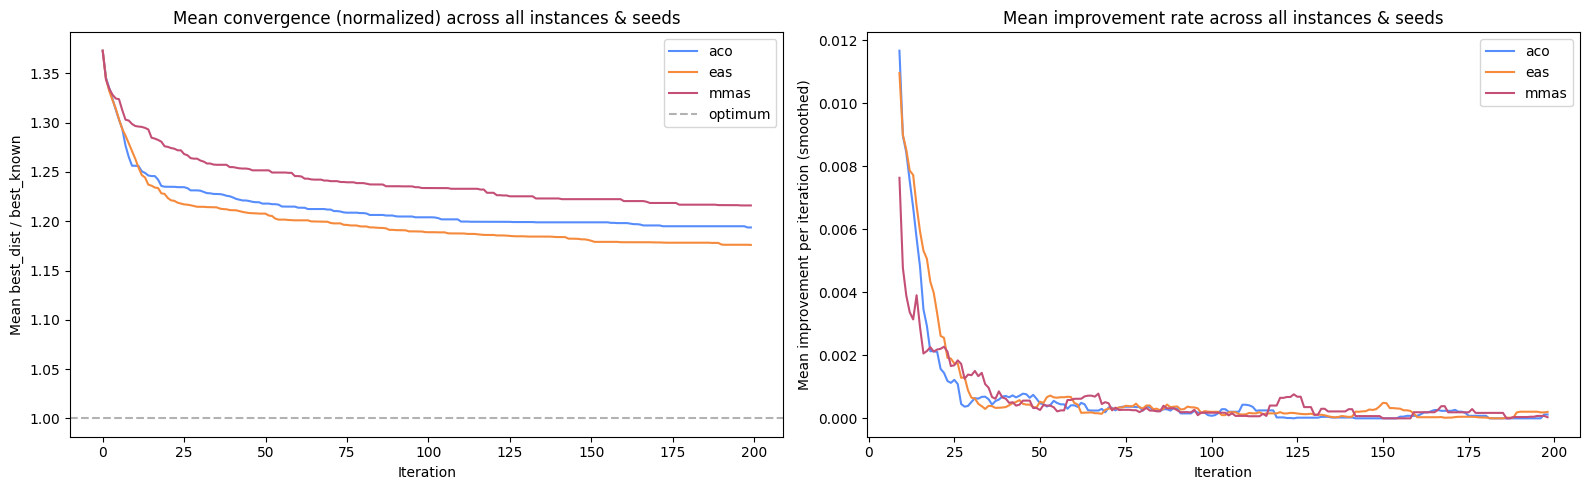

=== Stagnation per algorithm × instance (mean / min / max across seeds) ===


mean  min  max
algorithm instance                  
aco       B-n31-k5    82.2   41  136
          B-n39-k5   145.6    1  192
          B-n45-k6    99.4   37  150
          B-n50-k7   121.0   33  192
          B-n57-k9   104.8   33  158
          B-n78-k10   93.8   27  145
eas       B-n31-k5    74.0    9  119
          B-n39-k5    29.8    0   82
          B-n45-k6    63.0   19  108
          B-n50-k7    27.8   12   48
          B-n57-k9   100.6   49  161
          B-n78-k10   89.6   12  157
mmas      B-n31-k5    67.6    3  137
          B-n39-k5    96.0   22  140
          B-n45-k6    89.0   32  142
          B-n50-k7    92.6   31  177
          B-n57-k9    95.0    3  184
          B-n78-k10  114.2   10  169


=== Stagnation summary per algorithm (across all instances × seeds) ===


,mean,min,max,std
algorithm,,,,
aco,107.8,1,192,57.2
eas,64.1,0,161,46.9
mmas,92.4,3,184,52.5


In [19]:
json_files = list(MAIN_DIR.glob("*.json"))
instances = sorted(main["instance"].unique())

# --- Collect all unconstrained ACO-variant runs ---
from src.metrics import stagnation_length
all_runs = []
for jf in json_files:
    run = json.loads(jf.read_text())
    if not run.get("convergence") or run["algorithm"] == "greedy" or run.get("s_max") is not None:
        continue
    all_runs.append(run)

# --- Per-instance side-by-side plots (seed 42) ---
for target in instances:
    curves = {}
    for run in all_runs:
        if run["instance"] == target and run["seed"] == 42:
            curves[run["algorithm"]] = run["convergence"]
    if not curves:
        continue

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    for algo, curve in curves.items():
        ax1.plot(curve, label=algo)
    ax1.set_xlabel("Iteration"); ax1.set_ylabel("Best distance")
    ax1.set_title(f"{target} — Convergence (seed 42)"); ax1.legend()

    plot_convergence_derivative(curves, f"{target} — Improvement rate", ax=ax2)
    plt.tight_layout()
    plt.show()

# --- Aggregate convergence across ALL instances and seeds ---
# Group convergence curves per (algorithm, instance) by normalizing distance to the instance's best_known,
# then average across instances/seeds for each iteration.
def align_curves(curves, length):
    """Pad or truncate each curve to `length`."""
    out = []
    for c in curves:
        if len(c) >= length:
            out.append(c[:length])
        else:
            out.append(list(c) + [c[-1]] * (length - len(c)))
    return np.array(out)

# Collect per-algorithm curves, normalized by best_known per instance
best_known_by_inst = dict(zip(main["instance"], main["relative_error"] / main["relative_error"]))  # placeholder
# Rebuild using actual best_known from the first run per instance
bk_lookup = {}
for run in all_runs:
    inst = run["instance"]
    td = run["total_dist"]
    re = main[(main["instance"] == inst) & (main["algorithm"] == run["algorithm"]) & (main["seed"] == run["seed"])]
    if not re.empty and pd.notna(re.iloc[0]["relative_error"]):
        bk = td / (1 + re.iloc[0]["relative_error"])
        bk_lookup[inst] = bk

# Normalize: convergence[t] / best_known -> fraction above optimum
curves_by_algo = {}
for run in all_runs:
    algo = run["algorithm"]
    inst = run["instance"]
    if inst not in bk_lookup:
        continue
    bk = bk_lookup[inst]
    norm = [c / bk for c in run["convergence"]]
    curves_by_algo.setdefault(algo, []).append(norm)

# Plot mean convergence (normalized) and mean improvement rate across instances
if curves_by_algo:
    max_len = max(len(c) for curves in curves_by_algo.values() for c in curves)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    for algo, curves in curves_by_algo.items():
        arr = align_curves(curves, max_len)
        mean_curve = arr.mean(axis=0)
        ax1.plot(mean_curve, label=algo)

    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Mean best_dist / best_known")
    ax1.set_title("Mean convergence (normalized) across all instances & seeds")
    ax1.axhline(1.0, color="k", linestyle="--", alpha=0.3, label="optimum")
    ax1.legend()

    # Mean improvement rate (derivative) across instances
    window = 10
    for algo, curves in curves_by_algo.items():
        arr = align_curves(curves, max_len)
        mean_curve = arr.mean(axis=0)
        improvement = -np.diff(mean_curve)
        if len(improvement) >= window:
            kernel = np.ones(window) / window
            smoothed = np.convolve(improvement, kernel, mode="valid")
            ax2.plot(range(window - 1, window - 1 + len(smoothed)), smoothed, label=algo)
        else:
            ax2.plot(improvement, label=algo)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Mean improvement per iteration (smoothed)")
    ax2.set_title("Mean improvement rate across all instances & seeds")
    ax2.legend()
    plt.tight_layout()
    plt.show()

# --- Stagnation statistics: mean, min, max per algorithm × instance ---
records = []
for run in all_runs:
    records.append({
        "algorithm": run["algorithm"],
        "instance":  run["instance"],
        "stagnation": stagnation_length(run["convergence"]),
    })
if records:
    conv_df = pd.DataFrame(records)
    print("=== Stagnation per algorithm × instance (mean / min / max across seeds) ===")
    display(
        conv_df.groupby(["algorithm", "instance"])["stagnation"]
        .agg(["mean", "min", "max"]).round(1)
    )
    print("\n=== Stagnation summary per algorithm (across all instances × seeds) ===")
    display(
        conv_df.groupby("algorithm")["stagnation"]
        .agg(["mean", "min", "max", "std"]).round(1)
    )

## H3.4 — S_max & α/β Sensitivity

How tight distance constraints shift the optimal α/β parametrisation.


=== S_max=181 — mean total_dist by alpha/beta ===

=== S_max=226 — mean total_dist by alpha/beta ===

=== S_max=227 — mean total_dist by alpha/beta ===

=== S_max=284 — mean total_dist by alpha/beta ===

=== Dead-ends & success rate per alpha/beta ===


mean_dead_ends  mean_success_rate
algorithm alpha beta                                   
aco       0.5   1.0            5.081              0.919
                2.0            5.042              0.958
                5.0            5.026              0.974
          1.0   1.0            5.062              0.938
                2.0            5.040              0.960
                5.0            5.021              0.979
          2.0   1.0            5.020              0.980
                2.0            5.025              0.975
                5.0            5.032              0.968
eas       0.5   1.0            5.077              0.923
                2.0            5.045              0.955
                5.0            5.026              0.974
          1.0   1.0            5.040              0.960
                2.0            5.045              0.955
                5.0            5.020              0.980
          2.0   1.0            5.016              0.984
                2.0            5.010              0.990
                5.0            5.016              0.984
mmas      0.5   1.0            5.172              0.828
                2.0            5.086              0.914
                5.0            5.041              0.959
          1.0   1.0            5.173              0.827
                2.0            5.086              0.914
                5.0            5.041              0.959
          2.0   1.0            5.172              0.828
                2.0            5.085              0.915
                5.0            5.041              0.959

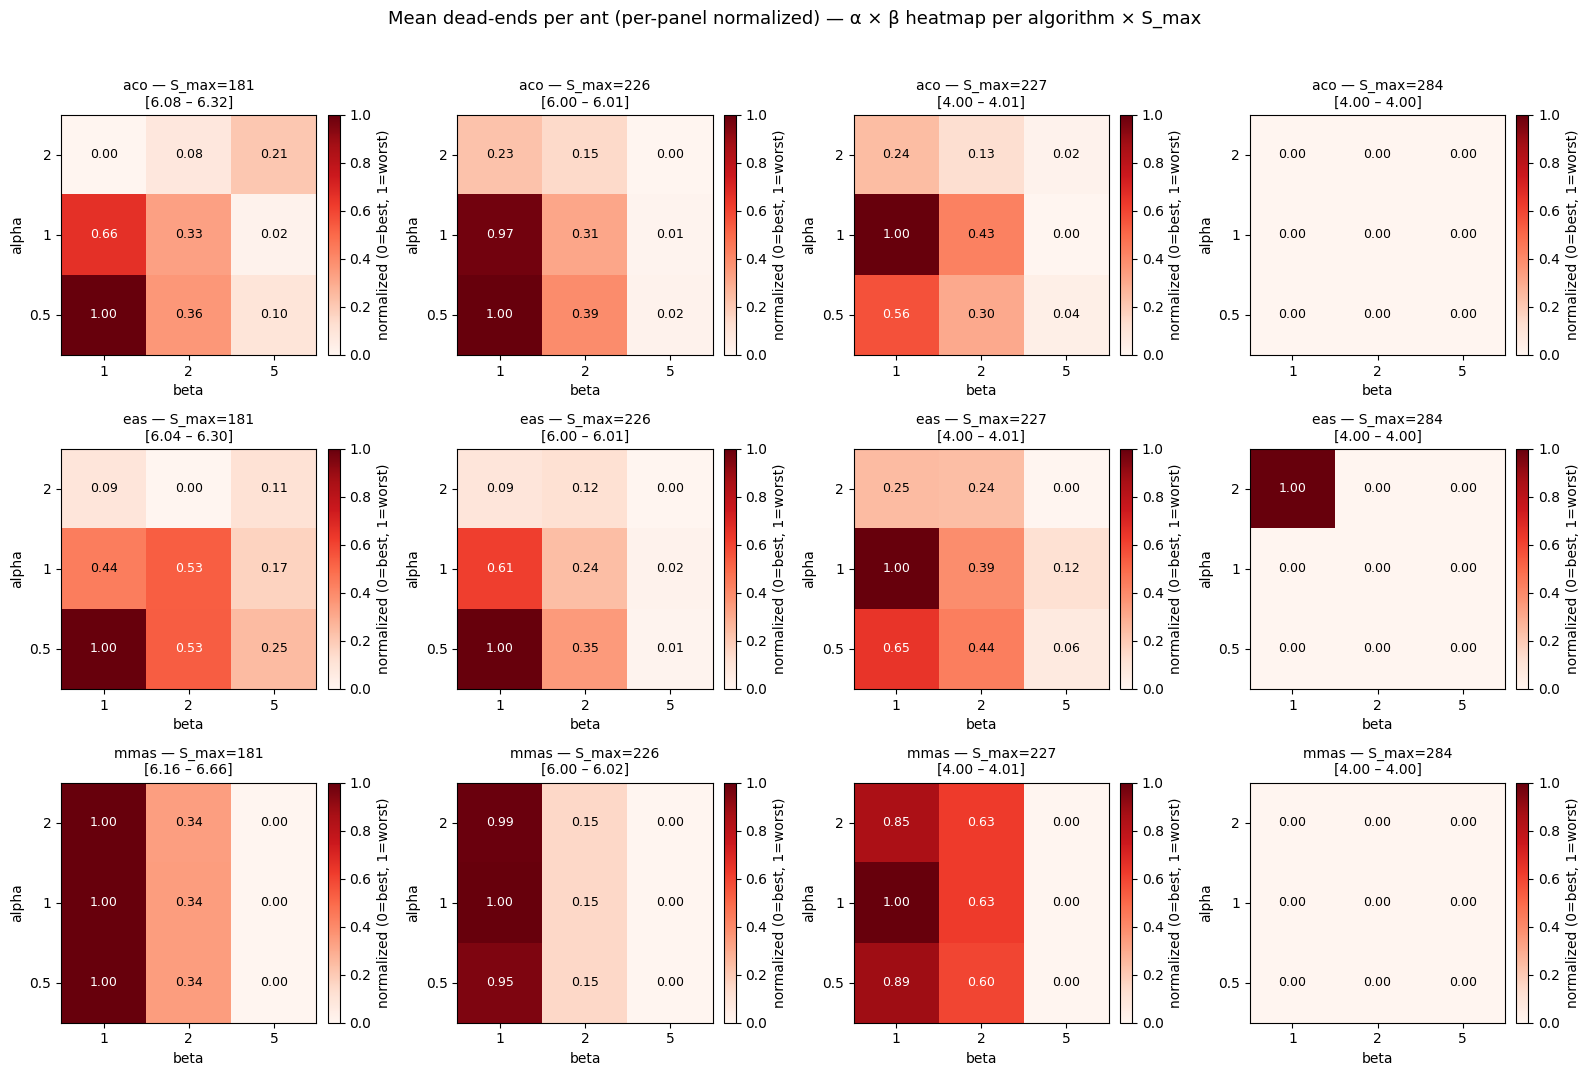

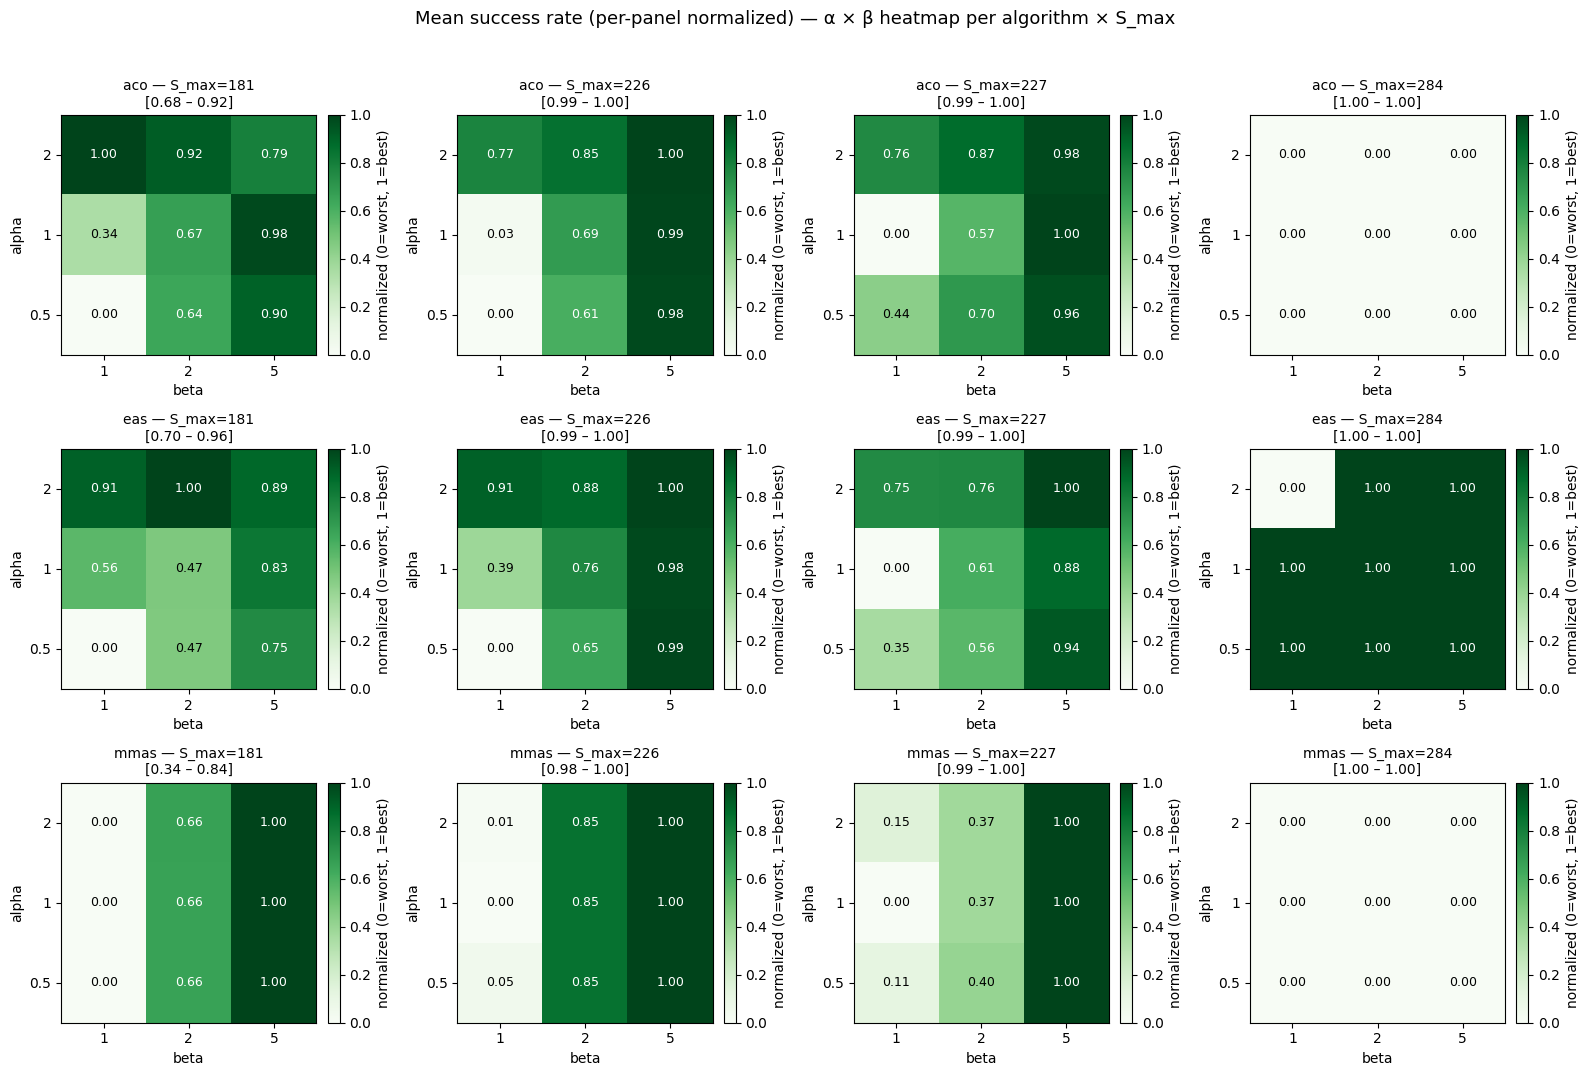

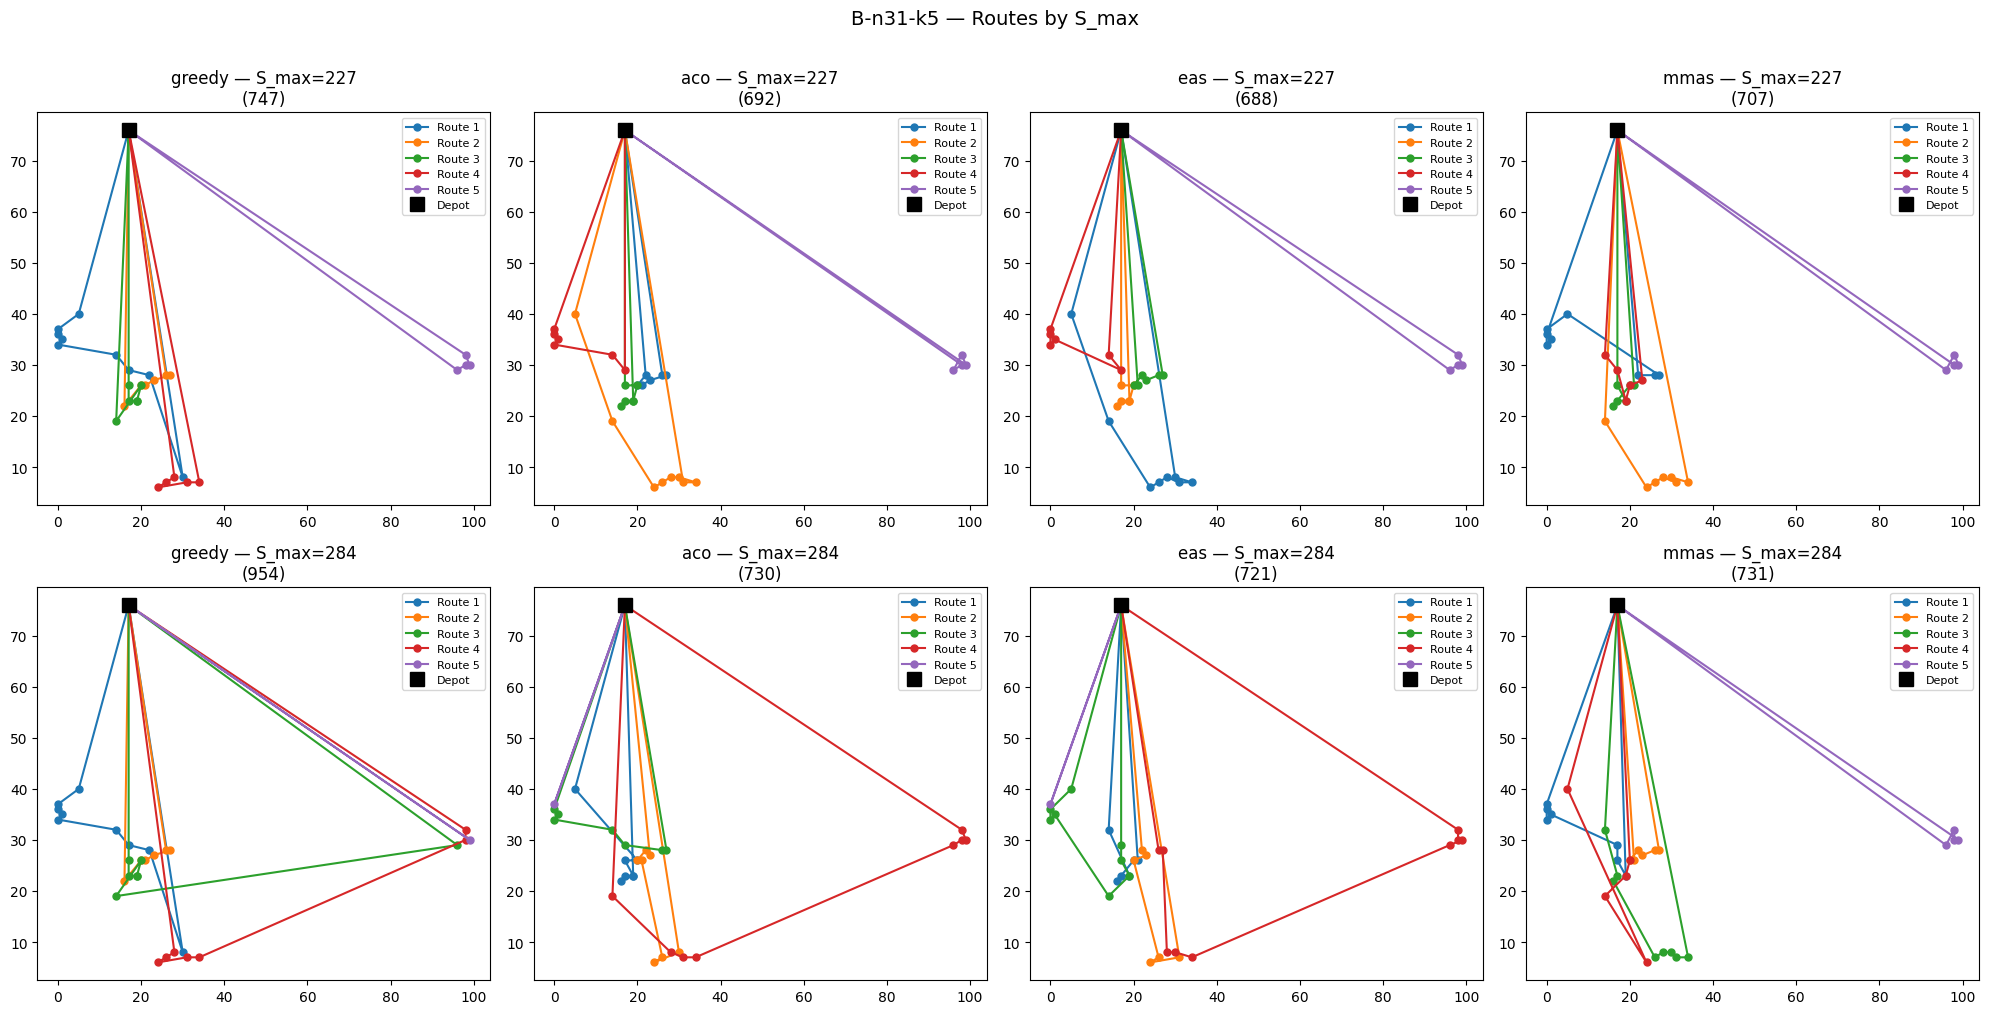

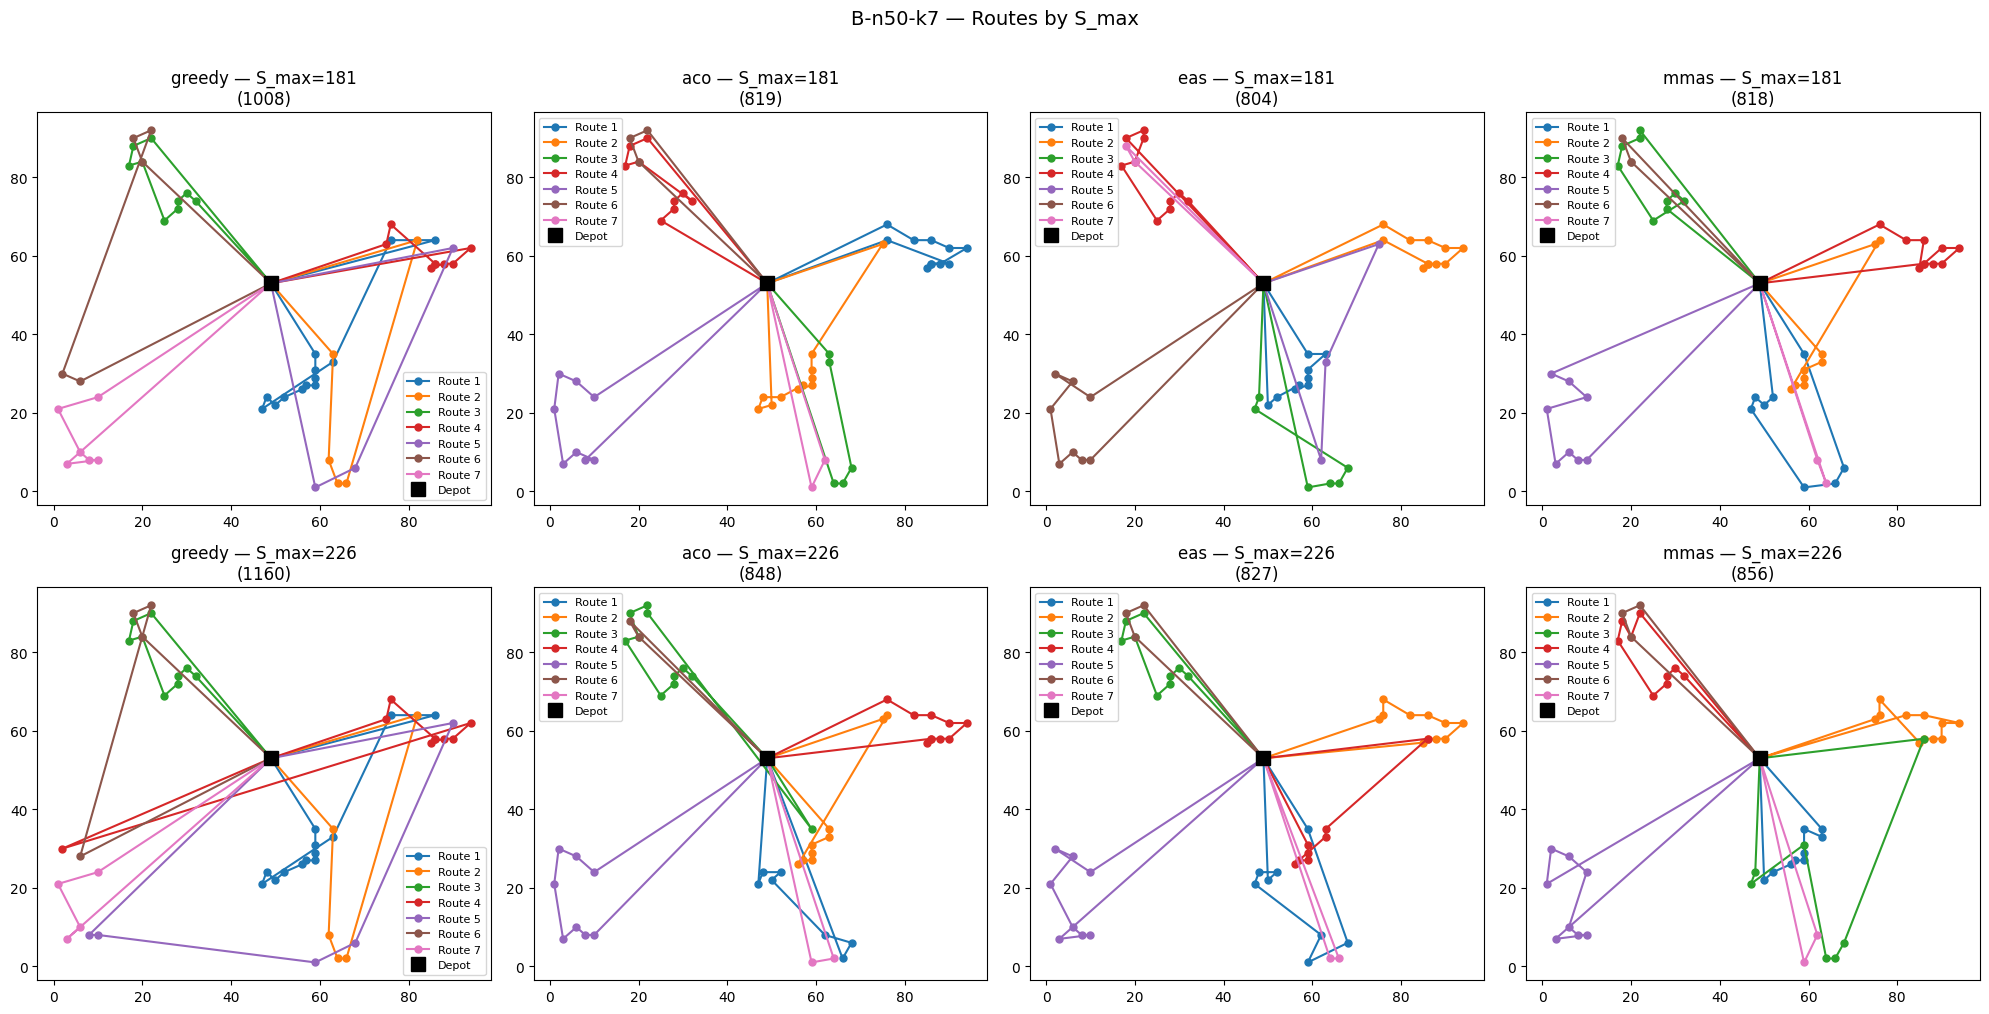

In [20]:
if SWEEP_DIR.exists() and (SWEEP_DIR / "results.csv").exists():
    sw = pd.read_csv(SWEEP_DIR / "results.csv")
    sw["feasible"] = sw["feasible"].astype(bool)
    sw["relative_error"] = pd.to_numeric(sw["relative_error"], errors="coerce")
    sw["s_max"] = pd.to_numeric(sw["s_max"], errors="coerce")

    # --- Sensitivity tables per S_max level ---
    for s_val in sorted(sw[sw["feasible"]]["s_max"].unique()):
        s_sub = sw[sw["feasible"] & (sw["s_max"] == s_val)]
        if s_sub.empty:
            continue
        label = f"S_max={s_val:.0f}" if not np.isnan(s_val) else "Unconstrained"
        print(f"\n=== {label} — mean total_dist by alpha/beta ===")
        if "param_alpha" in s_sub.columns and "param_beta" in s_sub.columns:
            display(
                s_sub.groupby(["algorithm", "param_alpha", "param_beta"])["total_dist"]
                .agg(["mean", "std", "count"]).round(1).sort_values("mean")
            )

    # --- Dead-end and success rate from JSON ---
    sr_records = []
    for jf in SWEEP_DIR.glob("*.json"):
        run = json.loads(jf.read_text())
        if not run.get("dead_end_ratio"):
            continue
        sr_records.append({
            "algorithm":         run["algorithm"],
            "instance":          run["instance"],
            "s_max":             run.get("s_max"),
            "alpha":             run.get("params", {}).get("alpha"),
            "beta":              run.get("params", {}).get("beta"),
            "mean_dead_ends":    sum(run["dead_end_ratio"]) / len(run["dead_end_ratio"]),
            "mean_success_rate": sum(run["success_rate"]) / len(run["success_rate"]),
        })
    if sr_records:
        sr_df = pd.DataFrame(sr_records)
        print("\n=== Dead-ends & success rate per alpha/beta ===")
        sr_con = sr_df[sr_df["s_max"].notna()]
        if not sr_con.empty:
            display(
                sr_con.groupby(["algorithm", "alpha", "beta"])
                [["mean_dead_ends", "mean_success_rate"]].mean().round(3)
            )

        # --- Heatmaps: dead-end ratio and success rate per α × β, per algorithm × S_max ---
        # Normalization: per-subplot min-max scaling so within-panel α/β patterns are visible.
        # Text labels show the raw value; color encodes the "distance from best in this panel".
        sr_algos = sorted([a for a in sr_df["algorithm"].unique() if a != "greedy"])
        s_max_vals = sorted([s for s in sr_df["s_max"].unique() if pd.notna(s)])

        for metric, cmap, title, better in [
            ("mean_dead_ends",    "Reds",   "Mean dead-ends per ant (per-panel normalized)", "low"),
            ("mean_success_rate", "Greens", "Mean success rate (per-panel normalized)",      "high"),
        ]:
            n_rows = len(sr_algos)
            n_cols = len(s_max_vals)
            if n_rows == 0 or n_cols == 0:
                continue
            fig, axes = plt.subplots(n_rows, n_cols,
                                     figsize=(4 * n_cols, 3.5 * n_rows),
                                     squeeze=False)
            for r, algo in enumerate(sr_algos):
                for c, s_val in enumerate(s_max_vals):
                    ax = axes[r, c]
                    sub = sr_df[(sr_df["algorithm"] == algo) & (sr_df["s_max"] == s_val)]
                    if sub.empty or sub["alpha"].isna().all():
                        ax.set_title(f"{algo} — S_max={s_val:.0f} (no data)")
                        ax.axis("off")
                        continue
                    pivot = sub.groupby(["alpha", "beta"])[metric].mean().unstack("beta")
                    pivot = pivot.sort_index(ascending=True)
                    pivot = pivot[sorted(pivot.columns)]
                    raw = pivot.values

                    # Per-subplot min-max normalization
                    vmin, vmax = np.nanmin(raw), np.nanmax(raw)
                    if vmax - vmin < 1e-9:
                        norm = np.zeros_like(raw)
                    else:
                        norm = (raw - vmin) / (vmax - vmin)
                    # For "high is better" metrics, invert so brighter = better
                    display_arr = norm if better == "low" else norm

                    im = ax.imshow(display_arr, aspect="auto", cmap=cmap,
                                   origin="lower", vmin=0.0, vmax=1.0)
                    ax.set_xticks(range(len(pivot.columns)))
                    ax.set_xticklabels([f"{b:g}" for b in pivot.columns])
                    ax.set_yticks(range(len(pivot.index)))
                    ax.set_yticklabels([f"{a:g}" for a in pivot.index])
                    ax.set_xlabel("beta")
                    ax.set_ylabel("alpha")
                    ax.set_title(f"{algo} — S_max={s_val:.0f}\n[{vmin:.2f} – {vmax:.2f}]",
                                 fontsize=10)
                    for i in range(raw.shape[0]):
                        for j in range(raw.shape[1]):
                            v = raw[i, j]
                            n = display_arr[i, j]
                            if not np.isnan(v):
                                ax.text(j, i, f"{n:.2f}", ha="center", va="center",
                                        color="white" if n > 0.5 else "black", fontsize=9)
                    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                                 label="normalized (0=best, 1=worst)" if better == "low"
                                 else "normalized (0=worst, 1=best)")
            fig.suptitle(f"{title} — α × β heatmap per algorithm × S_max", fontsize=13, y=1.02)
            plt.tight_layout()
            plt.show()

    # --- Route comparison at different S_max levels from JSON ---
    best_by_key = {}
    for jf in SWEEP_DIR.glob("*.json"):
        run = json.loads(jf.read_text())
        if not run.get("feasible") or not run.get("routes"):
            continue
        key = (run["instance"], run["algorithm"], run.get("s_max"))
        if key not in best_by_key or run["total_dist"] < best_by_key[key]["total_dist"]:
            best_by_key[key] = run

    sweep_instances = sorted({k[0] for k in best_by_key})
    sweep_algos = ["greedy", "aco", "eas", "mmas"]

    for inst_name in sweep_instances:
        vrp_path = DATA_DIR / f"{inst_name}.vrp"
        if not vrp_path.exists():
            continue
        inst = load_vrp(str(vrp_path))
        s_max_vals = sorted({k[2] for k in best_by_key if k[0] == inst_name},
                            key=lambda x: x if x is not None else float("inf"))

        n_rows = len(s_max_vals)
        n_cols = len(sweep_algos)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)
        for row, s_val in enumerate(s_max_vals):
            for col, algo in enumerate(sweep_algos):
                ax = axes[row, col]
                run = best_by_key.get((inst_name, algo, s_val))
                if run and run.get("routes"):
                    s_label = f"S_max={s_val:.0f}" if s_val is not None else "Unconstrained"
                    plot_routes(run["routes"], inst.coords,
                                f"{algo} — {s_label}\n({run['total_dist']:.0f})", ax=ax)
                else:
                    ax.set_title(f"{algo} — N/A"); ax.axis("off")
        fig.suptitle(f"{inst_name} — Routes by S_max", fontsize=14, y=1.01)
        plt.tight_layout()
        plt.show()
else:
    print("Sweep results not found — run sweep experiments first.")